In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
warnings = __import__("warnings")
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("aps_failure_training_set.csv", na_values="na")
test  = pd.read_csv("aps_failure_test_set.csv",  na_values="na")

In [3]:
train.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [5]:
train.shape

(60000, 171)

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 78.4 MB


In [7]:
train.describe()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.935500e+04,5.937100e+04,5.937100e+04,5.560000e+04,5.935800e+04,5.937100e+04,5.935800e+04,5.941100e+04,5.935800e+04,5.941100e+04,57277.000000,5.937100e+04,5.937100e+04,5.937100e+04,57500.000000,57499.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,59329.000000,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.931200e+04,5.935500e+04,57275.000000,57273.000000,57497.000000,57500.000000,5.935800e+04,5.935800e+04,5.941100e+04,5.941100e+04,3.696600e+04,3.272300e+04,2.045100e+04,1.599100e+04,1.366700e+04,1.226000e+04,1.127800e+04,1.073600e+04,5.927400e+04,5.983300e+04,5.930900e+04,5.930900e+04,5.674300e+04,5.952700e+04,5.727700e+04,55644.000000,5.927400e+04,5.674500e+04,59324.0,5.749800e+04,4.513900e+04,45139.000000,45139.000000,5.966200e+04,5.966200e+04,5.966200e+04,50447.000000,50123.000000,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,5.931300e+04,4.513900e+04,57276.000000,5.930900e+04,13671.000000,59331.000000,59331.000000,5.933100e+04,5.933100e+04,5.933100e+04,5.933100e+04,5.933100e+04,5.933100e+04,5.933100e+04,5.933100e+04,46192.000000,46192.000000,4.619200e+04,4.619200e+04,46192.000000,4.619200e+04,46192.000000,46192.000000,4.619200e+04,57497.000000,57276.000000,5.599200e+04,5.599200e+04,5.599200e+04,5.599400e+04,55993.000000,5.599300e+04,5.599200e+04,5.599100e+04,5.930900e+04,5.727600e+04,57274.000000,5.727400e+04,5.727400e+04,5.727300e+04,57273.000000,5.727400e+04,5.727400e+04,5.727700e+04,5.727600e+04,57277.000000,57277.000000,5.599300e+04,49761.000000,50447.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,4.370966e+05,1.108374e+06,1.657818e+06,4.993098e+05,3.556989e+04,5.114753e+03,1.809931e+06,9.016965e+03,1.143675e+03,9.794900e+02,5.913048e+04,9.328133e+04,3.461037e+06,3.002440e+06,1.004160e+06,4.424045e+05,0.496918,1.267365e+02,5.072046e+03,2.305804e+02,1117.825913,374.327380,1.221165e+04,1.019012e+04,1.097500e+04,7.225784e+03,1.056600e+04,1.119791e+05,1.078551e+06,1.546032e+06,1.051123e+06,1.162622e+03,7.849608e+03,4.420992e+03,8.066082e+03,8.724082e+04,1.476897e+06,2.1

In [8]:
#There are some rows that have large number of null values
todrop1=[]
for col in train.columns:
    if col!='class':
        null=(train[col].isna().mean())*100
        if null>=70:
            todrop1.append(col)

In [9]:
null = train.drop(columns=['class']).isna().mean() * 100

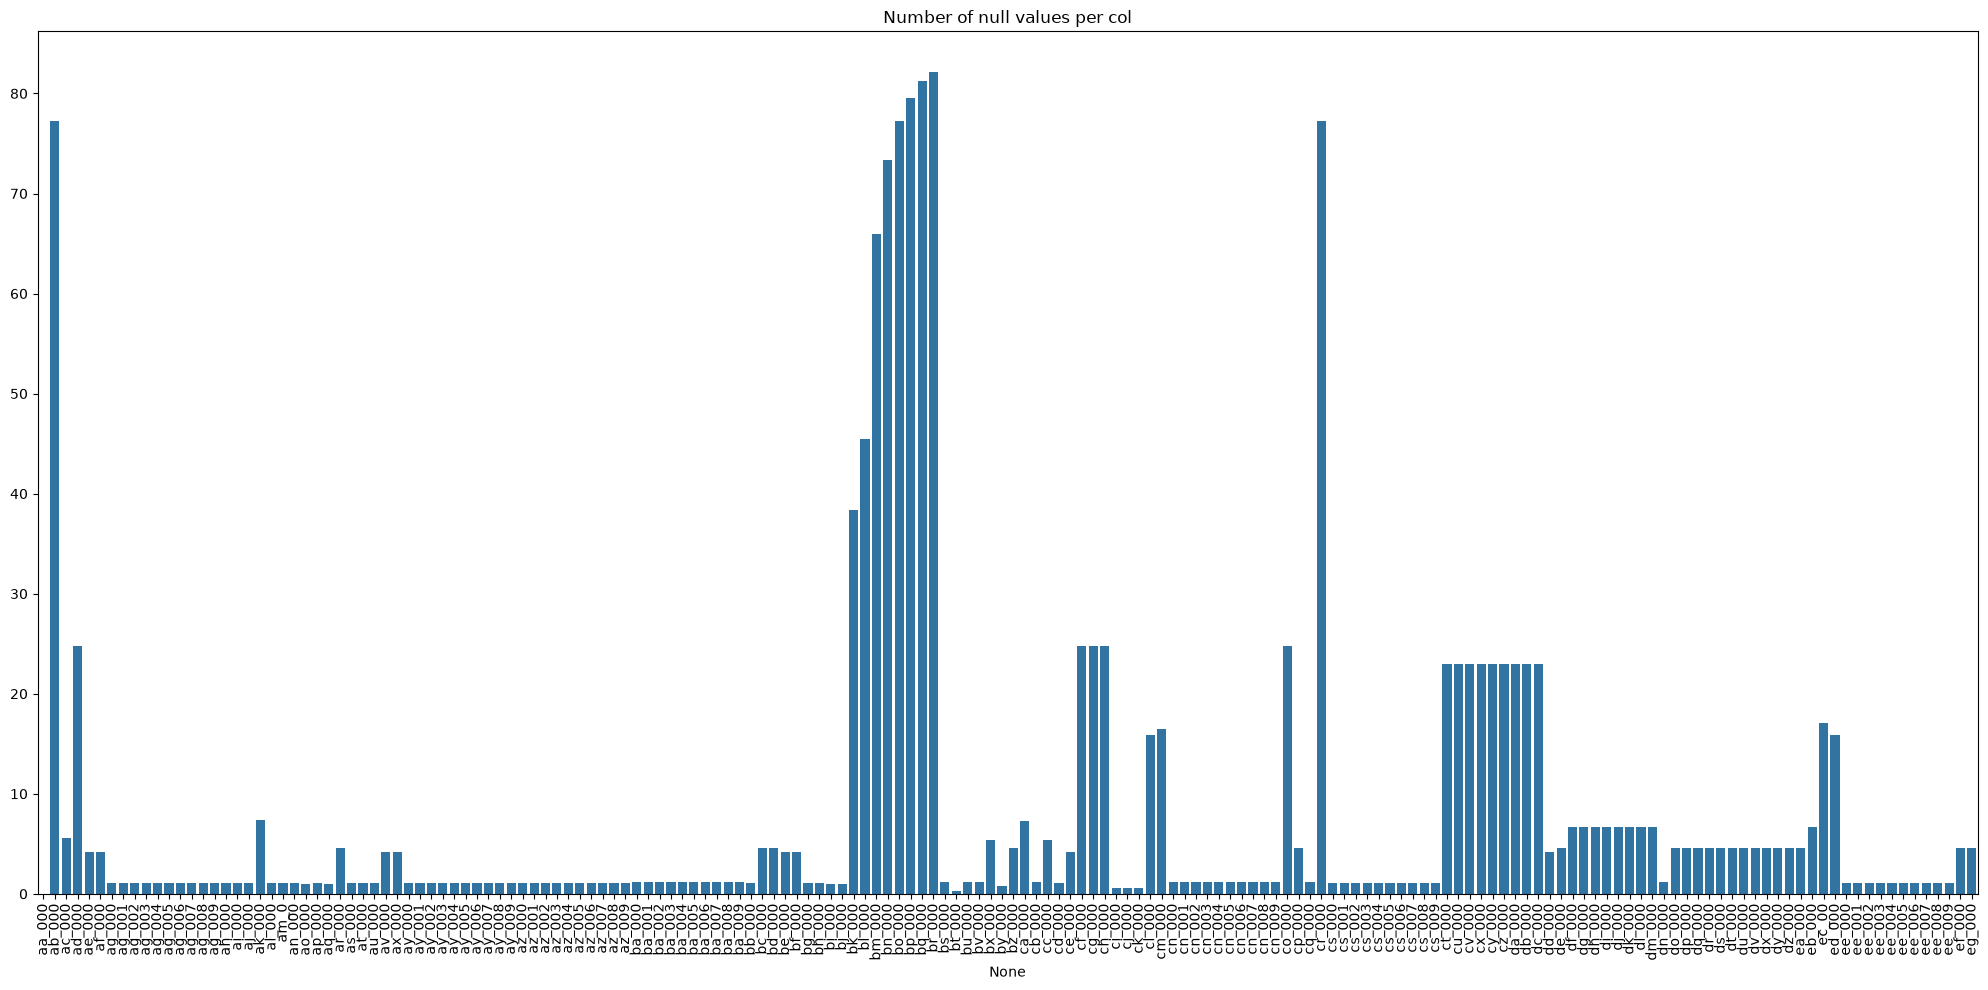

In [10]:
fig=plt.figure(figsize=(20,10))
sns.barplot(x=null.index,y=null.values)
plt.xticks(rotation=90)
plt.title('Number of null values per col')
plt.tight_layout()
plt.show()

In [11]:
todrop1

['ab_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cr_000']

In [12]:
train.drop(columns=todrop1,inplace=True)
test.drop(columns=todrop1,inplace=True)

In [13]:
numerical=train.select_dtypes(include=['number']).columns
numerical

Index(['aa_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001',
       'ag_002', 'ag_003', 'ag_004',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='str', length=163)

In [14]:
train[numerical]=train[numerical].fillna(train[numerical].mean())
test[numerical]=test[numerical].fillna(test[numerical].mean())

In [15]:
train['class']=train['class'].replace({'neg':0,'pos':1}).astype(int)
test['class']=test['class'].replace({'neg':0,'pos':1}).astype(int)

<Axes: xlabel='class', ylabel='count'>

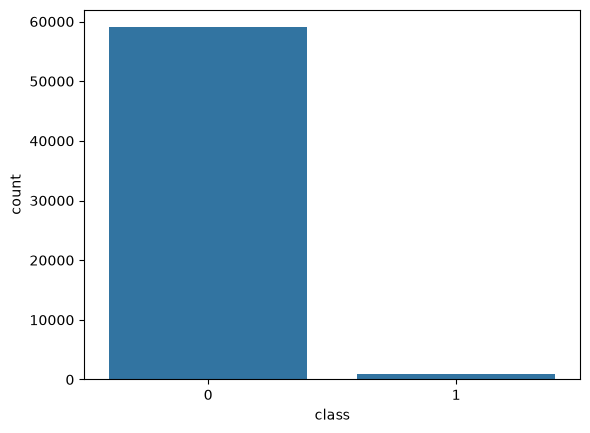

In [16]:
#to show class imbalance will use smote to resolve this
sns.countplot(train,x='class')

In [17]:
train.shape
train.duplicated().sum().sum()
train.drop_duplicates(inplace=True)

In [18]:
outlierdf={}
for col in train.columns:
    if col!='class':
        q1=train[col].quantile(0.25)
        q3=train[col].quantile(0.75)
        iqr=q3-q1
        upper=q3+1.5*iqr
        lower=q1-1.5*iqr
        outliers=((train[col]<lower)|(train[col]>upper)).sum()
        per=(outliers/len(train))*100
        outlierdf[col]={'count':outliers,'percentage':per}
summary=pd.DataFrame(outlierdf).T.sort_values(ascending=False,by='count')


In [19]:
summary.head()

,count,percentage
bm_000,16479.0,27.465458
cf_000,14925.0,24.875415
az_007,14906.0,24.843747
co_000,14905.0,24.842081
ad_000,14890.0,24.817080


<Axes: xlabel='None', ylabel='count'>

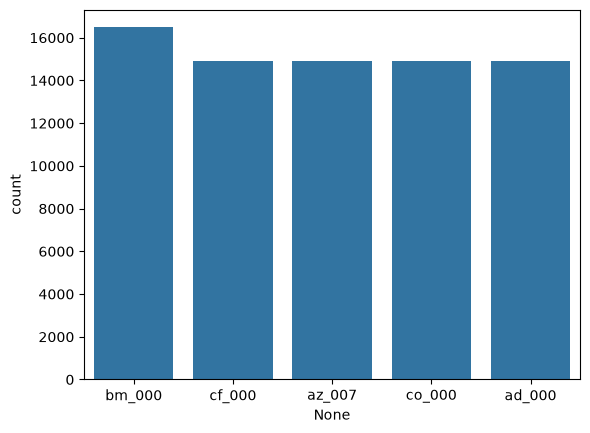

In [20]:
top5=summary.head()
sns.barplot(top5,y='count',x=top5.index)

In [21]:
#Now i will clip all the cols to upper and lower fences
for col in train.columns:
    if col!='class':
        q1=train[col].quantile(0.25)
        q3=train[col].quantile(0.75)
        iqr=q3-q1
        upper=q3+1.5*iqr
        lower=q1-1.5*iqr
        train[col]=train[col].clip(lower=lower,upper=upper)

In [22]:
corr = train.corr().abs()
upper= corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
todrop2 = [column for column in upper.columns if any(upper[column] > 0.85)]
print(f"Dropping {len(todrop2)} highly correlated columns: {todrop2}")

Dropping 64 highly correlated columns: ['ag_007', 'ah_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'az_001', 'az_002', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'bb_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'cb_000', 'cc_000', 'cf_000', 'ci_000', 'ck_000', 'cn_003', 'cn_004', 'cn_005', 'cn_006', 'cn_007', 'cn_008', 'cn_009', 'co_000', 'cq_000', 'cs_000', 'cs_001', 'cs_003', 'cs_004', 'cs_005', 'cs_007', 'cy_000', 'dc_000', 'dd_000', 'dn_000', 'dp_000', 'dr_000', 'ds_000', 'dt_000', 'dv_000', 'dy_000', 'ed_000', 'ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_007']


In [23]:
train.drop(columns=todrop2,inplace=True)
test.drop(columns=todrop2,inplace=True)

In [24]:
X_train=train.drop('class',axis=1)
y_train=train['class']
X_test=test.drop('class',axis=1)
y_test=test['class']

In [32]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
scaler=StandardScaler()
smote=SMOTE(random_state=42)

In [33]:
X_train_scaled=scaler.fit_transform(X_train)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train) 
X_test_scaled=scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

In [35]:
base_models = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('svr', SVC(probability=True, random_state=42,class_weight='balanced'))
]
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True,class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Gaussian NB": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "StackingClassifier": StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(max_iter=1000,class_weight='balanced')
    )
}

In [ ]:
score=[]
for i,(name,mod) in enumerate(models.items(),start=0):
    mod.fit(X_resampled,y_resampled)
    y_prediction=mod.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_prediction)
    f1=f1_score(y_test,y_prediction)
    y_pred_prob = mod.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    y_train_pred = mod.predict(X_resampled)
    train_acc = accuracy_score(y_resampled, y_train_pred)
    train_f1 = f1_score(y_resampled, y_train_pred)
    score.append({
        "Model_Name": name,
        "Test_Accuracy": acc,
        "Test_F1_Score": f1,
        "Test_AUC": auc,
        "Train_Accuracy": train_acc,
        "Train_F1_Score": train_f1
    })